In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
payment_events = pd.read_csv("/content/drive/MyDrive/razorpay hackathon dataset/payment_events.csv")
recovery_outcomes = pd.read_csv("/content/drive/MyDrive/razorpay hackathon dataset/recovery_outcomes.csv")

In [ ]:
print("Payment events:", payment_events.shape)
print("Recovery outcomes:", recovery_outcomes.shape)

Payment events: (5000, 12)
Recovery outcomes: (5000, 5)


In [ ]:
print("\nPayment columns:")
print(payment_events.columns.tolist())


Payment columns:
['transaction_id', 'customer_id', 'amount', 'failure_type', 'attempt_number', 'timestamp', 'total_orders', 'total_spend', 'avg_order_value', 'customer_tenure_days', 'cancelled_orders', 'cancellation_rate']


In [ ]:
print("\nOutcome columns:")
print(recovery_outcomes.columns.tolist())


Outcome columns:
['transaction_id', 'intervention', 'recovered', 'amount_recovered', 'recovery_time_hours']


In [ ]:
ml_df = payment_events.merge(
    recovery_outcomes,
    on="transaction_id",
    how="inner"
)

print("ML dataset:", ml_df.shape)
ml_df.head()

ML dataset: (5000, 16)


,transaction_id,customer_id,amount,failure_type,attempt_number,timestamp,total_orders,total_spend,avg_order_value,customer_tenure_days,cancelled_orders,cancellation_rate,intervention,recovered,amount_recovered,recovery_time_hours
0,TXN000001,13590.0,100.0,INSUFFICIENT_FUNDS,1,2025-07-02,12,4367.67,13.522198,362,2.0,0.166667,REMINDER,1,100.0,8.0
1,TXN000002,17550.0,100.0,INSUFFICIENT_FUNDS,1,2025-12-18,6,2280.48,7.809863,272,1.0,0.166667,PAYMENT_LINK,1,100.0,34.0
2,TXN000003,16635.0,100.0,LIMIT_EXCEEDED,1,2025-02-05,1,473.00,18.920000,0,0.0,0.000000,PAYMENT_LINK,1,100.0,59.0
3,TXN000004,13037.0,100.0,TIMEOUT,1,2025-02-06,9,3033.88,16.488478,336,4.0,0.444444,RETRY,1,100.0,18.0
4,TXN000005,17121.0,100.0,LIMIT_EXCEEDED,1,2025-01-14,1,314.74,26.228333,0,0.0,0.000000,PAYMENT_LINK,0,0.0,NaN


In [ ]:
features = [
    "amount",
    "attempt_number",
    "total_orders",
    "total_spend",
    "avg_order_value",
    "customer_tenure_days",
    "cancelled_orders",
    "cancellation_rate",
    "failure_type"
]

target = "recovered"

X = ml_df[features].copy()
y = ml_df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 9)
y shape: (5000,)


In [ ]:
print(y.value_counts())
print()
print(y.value_counts(normalize=True))

recovered
1    3087
0    1913
Name: count, dtype: int64

recovered
1    0.6174
0    0.3826
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

features = [
    "amount",
    "attempt_number",
    "total_orders",
    "total_spend",
    "avg_order_value",
    "customer_tenure_days",
    "cancelled_orders",
    "cancellation_rate",
    "failure_type"
]

X = ml_df[features].copy()
y = ml_df["recovered"].copy()

# 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

print("\nTarget distribution:")
print(y_train.value_counts(normalize=True))

Training: (3500, 9)
Validation: (750, 9)
Testing: (750, 9)

Target distribution:
recovered
1    0.617429
0    0.382571
Name: proportion, dtype: float64


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "failure_type"
]

numeric_features = [
    "amount",
    "attempt_number",
    "total_orders",
    "total_spend",
    "avg_order_value",
    "customer_tenure_days",
    "cancelled_orders",
    "cancellation_rate"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

In [ ]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_model)
    ]
)

In [ ]:
pipeline.fit(X_train,y_train)
print("✅ XGBoost training completed!")

✅ XGBoost training completed!


In [ ]:
y_pred = pipeline.predict(X_test)

In [ ]:
y_prob = pipeline.predict_proba(X_test)[:, 1]

In [ ]:
results = pd.DataFrame({"actual": y_test.values,"predicted": y_pred,"recovery_probability": y_prob})
results.head(10)

,actual,predicted,recovery_probability
0,0,1,0.741073
1,1,1,0.840523
2,1,1,0.669292
3,1,1,0.633614
4,1,1,0.793372
5,1,1,0.762102
6,1,0,0.471210
7,1,0,0.476462
8,0,0,0.310076
9,1,1,0.810260


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("===== REVIVEAI XGBOOST RESULTS =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

===== REVIVEAI XGBOOST RESULTS =====
Accuracy : 0.6520
Precision: 0.6836
Recall   : 0.8121
F1 Score : 0.7423
ROC-AUC  : 0.6552


In [ ]:
from sklearn.metrics import classification_report
print(
    classification_report(y_test,y_pred,target_names=["Not Recovered", "Recovered"]))

               precision    recall  f1-score   support

Not Recovered       0.56      0.39      0.46       287
    Recovered       0.68      0.81      0.74       463

     accuracy                           0.65       750
    macro avg       0.62      0.60      0.60       750
 weighted avg       0.64      0.65      0.64       750



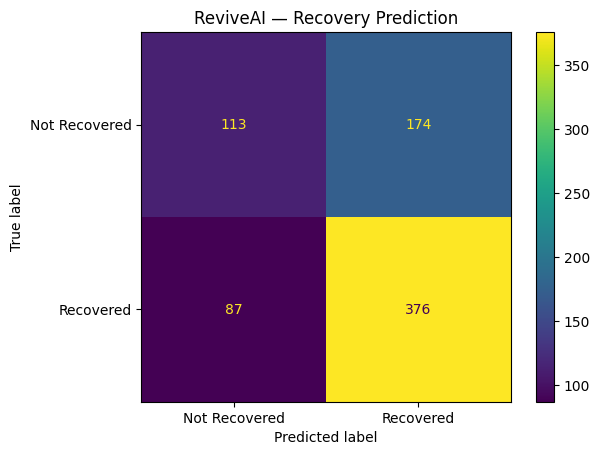

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Not Recovered",
        "Recovered"])
disp.plot()
plt.title("ReviveAI — Recovery Prediction")
plt.show()

In [ ]:
feature_names = (
    pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    pipeline
    .named_steps["model"]
    .feature_importances_
)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

print(importance_df.head(15))

                                         feature  importance
6        categorical__failure_type_UNKNOWN_ERROR    0.177311
3       categorical__failure_type_LIMIT_EXCEEDED    0.105534
1         categorical__failure_type_CARD_EXPIRED    0.084320
4        categorical__failure_type_NETWORK_ERROR    0.081707
14                    numeric__cancellation_rate    0.080921
0        categorical__failure_type_BANK_DECLINED    0.075750
13                     numeric__cancelled_orders    0.057839
5              categorical__failure_type_TIMEOUT    0.055628
10                          numeric__total_spend    0.052093
11                      numeric__avg_order_value    0.051592
9                          numeric__total_orders    0.050488
12                 numeric__customer_tenure_days    0.048009
2   categorical__failure_type_INSUFFICIENT_FUNDS    0.043483
7                                numeric__amount    0.035326
8                        numeric__attempt_number    0.000000


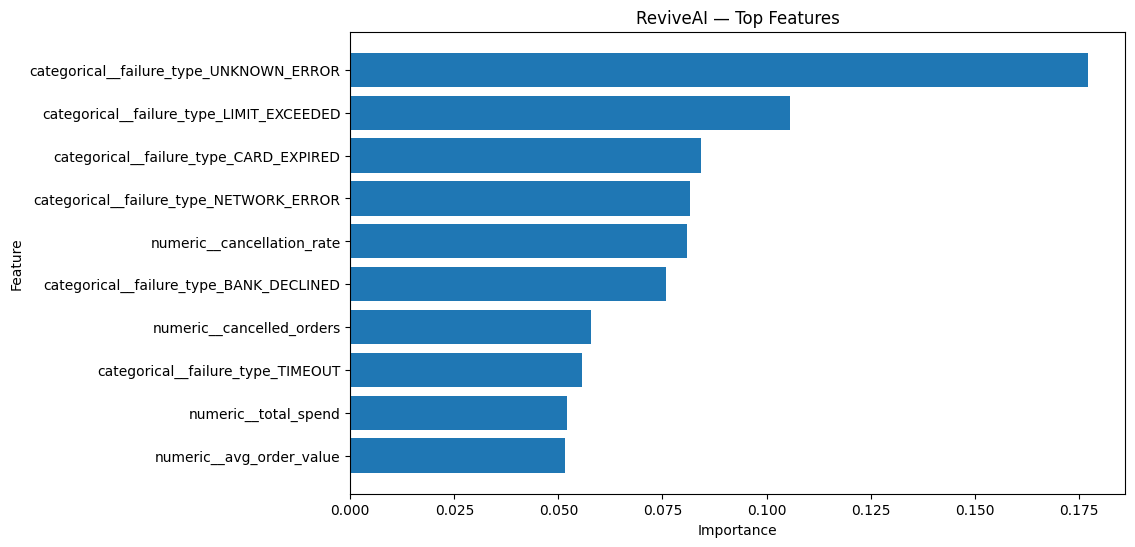

In [ ]:
top_features = importance_df.head(10).sort_values("importance")
plt.figure(figsize=(10, 6))
plt.barh(
    top_features["feature"],
    top_features["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("ReviveAI — Top Features")
plt.show()

In [ ]:
import joblib

joblib.dump(
    pipeline,
    "/content/drive/MyDrive/razorpay hackathon dataset/reviveai_xgboost_model.pkl")

print("✅ Model saved!")

In [ ]:
def recovery_policy(row, probability):

    amount = row["amount"]
    failure = row["failure_type"]

    # Hard safety limit
    if amount > 15000:
        return {
            "action": "ESCALATE",
            "reason": "Transaction exceeds automatic recovery limit",
            "approved": False
        }

    # High confidence
    if probability >= 0.80:

        if failure in ["NETWORK_ERROR", "TIMEOUT"]:
            return {
                "action": "RETRY",
                "reason": "High recovery probability and temporary payment failure",
                "approved": True
            }

        elif failure == "CARD_EXPIRED":
            return {
                "action": "UPDATE_CARD",
                "reason": "Payment method appears invalid",
                "approved": True
            }

        elif failure == "INSUFFICIENT_FUNDS":
            return {
                "action": "REMINDER",
                "reason": "High recovery probability but balance may be insufficient",
                "approved": True
            }

    # Medium confidence
    if probability >= 0.50:

        return {
            "action": "PAYMENT_LINK",
            "reason": "Moderate recovery probability; customer-driven payment preferred",
            "approved": True
        }

    # Low confidence
    return {
        "action": "ESCALATE",
        "reason": "Low recovery probability; automatic action avoided",
        "approved": False
    }

In [ ]:
test_results = X_test.copy()

test_results["actual_recovered"] = y_test.values
test_results["recovery_probability"] = y_prob

In [ ]:
test_results["decision"] = test_results.apply(
    lambda row: recovery_policy(
        row,
        row["recovery_probability"]
    ),
    axis=1
)

In [ ]:
test_results["action"] = test_results["decision"].apply(
    lambda x: x["action"])

test_results["reason"] = test_results["decision"].apply(
    lambda x: x["reason"])

test_results["approved"] = test_results["decision"].apply(
    lambda x: x["approved"])

In [ ]:
test_results[
    [
        "amount",
        "failure_type",
        "recovery_probability",
        "action",
        "approved",
        "reason"
    ]
].head(20)

,amount,failure_type,recovery_probability,action,approved,reason
1811,100.00,NETWORK_ERROR,0.741073,PAYMENT_LINK,True,Moderate recovery probability; customer-driven...
211,100.00,TIMEOUT,0.840523,RETRY,True,High recovery probability and temporary paymen...
3455,100.00,NETWORK_ERROR,0.669292,PAYMENT_LINK,True,Moderate recovery probability; customer-driven...
1407,100.00,TIMEOUT,0.633614,PAYMENT_LINK,True,Moderate recovery probability; customer-driven...
3875,100.00,NETWORK_ERROR,0.793372,PAYMENT_LINK,True,Moderate recovery probability; customer-driven...
1120,2622.65,NETWORK_ERROR,0.762102,PAYMENT_LINK,True,Moderate recovery probability; customer-driven...
399,100.00,LIMIT_EXCEEDED,0.471210,ESCALATE,False,Low recovery probability; automatic action avo...
565,100.00,NETWORK_ERROR,0.476462,ESCALATE,False,Low recovery probability; automatic action avo...
4285,100.00,BANK_DECLINED,0.310076,ESCALATE,False,Low recovery probability; automatic action avo...
2429,100.00,CARD_EXPIRED,0.810260,UPDATE_CARD,True,Payment method appears invalid


In [ ]:
test_results["actual_amount_recovered"] = np.where(
    test_results["actual_recovered"] == 1,
    test_results["amount"],
    0)

In [ ]:
total_at_risk = test_results["amount"].sum()

actual_recovered = test_results[
    "actual_amount_recovered"
].sum()

print(f"Total revenue at risk: ₹{total_at_risk:,.2f}")
print(f"Actual revenue recovered: ₹{actual_recovered:,.2f}")

Total revenue at risk: ₹118,495.41
Actual revenue recovered: ₹75,353.37


In [ ]:
action_summary = test_results.groupby("action").agg(
    transactions=("action", "count"),
    recovery_rate=("actual_recovered", "mean"),
    revenue_recovered=("actual_amount_recovered", "sum")
).sort_values(
    "revenue_recovered",
    ascending=False
)

action_summary

,transactions,recovery_rate,revenue_recovered
action,,,
PAYMENT_LINK,415,0.653012,43193.86
RETRY,89,0.797753,19787.11
ESCALATE,200,0.435000,8779.38
UPDATE_CARD,34,0.764706,2658.17
REMINDER,12,0.666667,934.85


In [ ]:
audit_log = test_results[
    [
        "amount",
        "failure_type",
        "recovery_probability",
        "action",
        "approved",
        "reason",
        "actual_recovered",
        "actual_amount_recovered"
    ]
].copy()

audit_log["timestamp"] = pd.Timestamp.now()

audit_log.head()

,amount,failure_type,recovery_probability,action,approved,reason,actual_recovered,actual_amount_recovered,timestamp
1811,100.0,NETWORK_ERROR,0.741073,PAYMENT_LINK,True,Moderate recovery probability; customer-driven...,0,0.0,2026-08-31 16:50:05.011400
211,100.0,TIMEOUT,0.840523,RETRY,True,High recovery probability and temporary paymen...,1,100.0,2026-08-31 16:50:05.011400
3455,100.0,NETWORK_ERROR,0.669292,PAYMENT_LINK,True,Moderate recovery probability; customer-driven...,1,100.0,2026-08-31 16:50:05.011400
1407,100.0,TIMEOUT,0.633614,PAYMENT_LINK,True,Moderate recovery probability; customer-driven...,1,100.0,2026-08-31 16:50:05.011400
3875,100.0,NETWORK_ERROR,0.793372,PAYMENT_LINK,True,Moderate recovery probability; customer-driven...,1,100.0,2026-08-31 16:50:05.011400


In [ ]:
audit_log.to_csv(
    "/content/drive/MyDrive/razorpay hackathon dataset/reviveai_audit_log.csv",
    index=False
)

In [ ]:
total_transactions = len(test_results)

total_at_risk = test_results["amount"].sum()

total_recovered = test_results["actual_amount_recovered"].sum()

overall_recovery_rate = (
    test_results["actual_recovered"].mean()
)

print("Total transactions:", total_transactions)
print(f"Revenue at risk: ₹{total_at_risk:,.2f}")
print(f"Revenue recovered: ₹{total_recovered:,.2f}")
print(f"Overall recovery rate: {overall_recovery_rate:.2%}")

Total transactions: 750
Revenue at risk: ₹118,495.41
Revenue recovered: ₹75,353.37
Overall recovery rate: 61.73%


In [ ]:
import joblib
model = joblib.load("/content/drive/MyDrive/razorpay hackathon dataset/reviveai_xgboost_model.pkl")
print("✅ ReviveAI model loaded")

✅ ReviveAI model loaded


In [ ]:
MAX_AUTO_AMOUNT = 15000
MAX_RETRIES = 2

def policy_engine(row, probability, retry_count=0):

    amount = row["amount"]
    failure_type = row["failure_type"]

    # Rule 1: High-value transactions require human review
    if amount > MAX_AUTO_AMOUNT:
        return {
            "action": "ESCALATE",
            "approved": False,
            "reason": "Transaction exceeds automatic recovery limit"
        }

    # Rule 2: Never exceed retry limit
    if retry_count >= MAX_RETRIES:
        return {
            "action": "ESCALATE",
            "approved": False,
            "reason": "Maximum retry limit reached"
        }

    # Rule 3: High probability
    if probability >= 0.80:

        if failure_type in ["NETWORK_ERROR", "TIMEOUT"]:
            return {
                "action": "RETRY",
                "approved": True,
                "reason": "High recovery probability and temporary payment failure"
            }

        if failure_type == "CARD_EXPIRED":
            return {
                "action": "UPDATE_CARD",
                "approved": True,
                "reason": "Payment method requires customer update"
            }

        if failure_type == "INSUFFICIENT_FUNDS":
            return {
                "action": "REMINDER",
                "approved": True,
                "reason": "Customer has high recovery likelihood; reminder is safer than repeated retry"
            }

    # Rule 4: Medium probability
    if probability >= 0.50:
        return {
            "action": "PAYMENT_LINK",
            "approved": True,
            "reason": "Moderate recovery probability; customer-initiated payment preferred"
        }

    # Rule 5: Low probability
    return {
        "action": "ESCALATE",
        "approved": False,
        "reason": "Low recovery probability; automatic recovery avoided"
    }

In [ ]:
test_transaction = {
    "amount": 2500,
    "failure_type": "NETWORK_ERROR"}

decision = policy_engine(
    test_transaction,
    probability=0.87
)
print(decision)

{'action': 'RETRY', 'approved': True, 'reason': 'High recovery probability and temporary payment failure'}


In [ ]:
test_transaction = {
    "amount": 20000,
    "failure_type": "NETWORK_ERROR"}

decision = policy_engine(
    test_transaction,
    probability=0.92
)

print(decision)

{'action': 'ESCALATE', 'approved': False, 'reason': 'Transaction exceeds automatic recovery limit'}


In [ ]:
test_transaction = {
    "amount": 3000,
    "failure_type": "BANK_DECLINED"
}

decision = policy_engine(
    test_transaction,
    probability=0.28
)

print(decision)

{'action': 'ESCALATE', 'approved': False, 'reason': 'Low recovery probability; automatic recovery avoided'}


In [ ]:
def recovery_agent(row):

    # Create a one-row DataFrame
    input_df = pd.DataFrame([row])

    # Predict probability
    probability = model.predict_proba(input_df)[0][1]

    # Apply policy
    decision = policy_engine(
        row,
        probability,
        retry_count=row.get("retry_count", 0)
    )

    return {
        "transaction_id": row.get("transaction_id"),
        "amount": row["amount"],
        "failure_type": row["failure_type"],
        "recovery_probability": round(float(probability), 4),
        "action": decision["action"],
        "approved": decision["approved"],
        "reason": decision["reason"]
    }

In [ ]:
sample = payment_events.iloc[0].to_dict()
result = recovery_agent(sample)
result

{'transaction_id': 'TXN000001',
 'amount': 100.0,
 'failure_type': 'INSUFFICIENT_FUNDS',
 'recovery_probability': 0.6089,
 'action': 'PAYMENT_LINK',
 'approved': True,
 'reason': 'Moderate recovery probability; customer-initiated payment preferred'}

In [ ]:
agent_results = []

for _, row in X_test.iterrows():

    result = recovery_agent(row.to_dict())

    agent_results.append(result)

agent_results = pd.DataFrame(agent_results)

print("Processed transactions:", len(agent_results))

agent_results.head()

Processed transactions: 750


,transaction_id,amount,failure_type,recovery_probability,action,approved,reason
0,None,100.0,NETWORK_ERROR,0.7411,PAYMENT_LINK,True,Moderate recovery probability; customer-initia...
1,None,100.0,TIMEOUT,0.8405,RETRY,True,High recovery probability and temporary paymen...
2,None,100.0,NETWORK_ERROR,0.6693,PAYMENT_LINK,True,Moderate recovery probability; customer-initia...
3,None,100.0,TIMEOUT,0.6336,PAYMENT_LINK,True,Moderate recovery probability; customer-initia...
4,None,100.0,NETWORK_ERROR,0.7934,PAYMENT_LINK,True,Moderate recovery probability; customer-initia...


In [ ]:
agent_results["action"].value_counts()

,count
action,
PAYMENT_LINK,415
ESCALATE,200
RETRY,89
UPDATE_CARD,34
REMINDER,12


In [ ]:
approval_rate = agent_results["approved"].mean()

print(f"Automatic action approval rate: {approval_rate:.2%}")

Automatic action approval rate: 73.33%


In [ ]:
def execute_recovery(action, probability):

    if action == "RETRY":
        # Higher probability → higher chance of success
        success_probability = min(
            0.95,
            probability + 0.05
        )

        return np.random.random() < success_probability

    elif action == "PAYMENT_LINK":
        success_probability = min(
            0.90,
            probability
        )

        return np.random.random() < success_probability

    elif action == "UPDATE_CARD":
        success_probability = min(
            0.95,
            probability + 0.10
        )

        return np.random.random() < success_probability

    elif action == "REMINDER":
        success_probability = min(
            0.85,
            probability
        )

        return np.random.random() < success_probability

    else:
        # Escalation does not automatically recover money
        return False

In [ ]:
np.random.seed(42)

agent_results["execution_success"] = agent_results.apply(
    lambda row: (
        execute_recovery(
            row["action"],
            row["recovery_probability"]
        )
        if row["approved"]
        else False
    ),
    axis=1
)

In [ ]:
agent_results = agent_results.merge(
    payment_events[
        ["transaction_id", "amount"]
    ],
    on="transaction_id",
    how="left",
    suffixes=("", "_original")
)

In [ ]:
agent_results["simulated_revenue_recovered"] = np.where(
    agent_results["execution_success"],
    agent_results["amount"],
    0)

In [ ]:
total_recovered_by_agent = (
    agent_results["simulated_revenue_recovered"].sum())
print(f"🤖 ReviveAI simulated revenue recovered: ₹{total_recovered_by_agent:,.2f}")

🤖 ReviveAI simulated revenue recovered: ₹78,264.13


In [ ]:
audit_log = agent_results[
    [
        "transaction_id",
        "amount",
        "failure_type",
        "recovery_probability",
        "action",
        "approved",
        "reason",
        "execution_success",
        "simulated_revenue_recovered"
    ]
].copy()

audit_log["timestamp"] = pd.Timestamp.now()

audit_log.head()

,transaction_id,amount,failure_type,recovery_probability,action,approved,reason,execution_success,simulated_revenue_recovered,timestamp
0,None,100.0,NETWORK_ERROR,0.7411,PAYMENT_LINK,True,Moderate recovery probability; customer-initia...,True,100.0,2026-08-31 16:52:01.669774
1,None,100.0,TIMEOUT,0.8405,RETRY,True,High recovery probability and temporary paymen...,False,0.0,2026-08-31 16:52:01.669774
2,None,100.0,NETWORK_ERROR,0.6693,PAYMENT_LINK,True,Moderate recovery probability; customer-initia...,False,0.0,2026-08-31 16:52:01.669774
3,None,100.0,TIMEOUT,0.6336,PAYMENT_LINK,True,Moderate recovery probability; customer-initia...,True,100.0,2026-08-31 16:52:01.669774
4,None,100.0,NETWORK_ERROR,0.7934,PAYMENT_LINK,True,Moderate recovery probability; customer-initia...,True,100.0,2026-08-31 16:52:01.669774


In [ ]:
audit_log.to_csv(
    "/content/drive/MyDrive/razorpay hackathon dataset/reviveai_agent_audit_log.csv",
    index=False
)

print("✅ Audit log saved")

In [ ]:
audit_log.iloc[0]

In [ ]:
def should_stop(retry_count, success):

    if success:
        return True, "Payment recovered successfully"

    if retry_count >= MAX_RETRIES:
        return True, "Maximum retry limit reached"

    return False, "Retry permitted"

In [ ]:
print(should_stop(0, False))
print(should_stop(1, False))
print(should_stop(2, False))
print(should_stop(1, True))

(False, 'Retry permitted')
(False, 'Retry permitted')
(True, 'Maximum retry limit reached')
(True, 'Payment recovered successfully')


Agent's Reasoning Layer

In [ ]:
def explain_decision(row, probability, decision):

    action = decision["action"]
    approved = decision["approved"]
    reason = decision["reason"]

    explanation = f"""
REVIVEAI RECOVERY DECISION
--------------------------

Transaction: {row.get('transaction_id', 'N/A')}
Amount: ₹{row['amount']:,.2f}
Failure Type: {row['failure_type']}

Recovery Probability: {probability:.2%}

Recommended Action: {action}

Approval Status: {"APPROVED" if approved else "BLOCKED"}

Reason:
{reason}
"""

    return explanation

In [ ]:
sample = payment_events.iloc[0].to_dict()

input_df = pd.DataFrame([sample])

probability = model.predict_proba(input_df)[0][1]

decision = policy_engine(
    sample,
    probability
)

print(
    explain_decision(
        sample,
        probability,
        decision
    )
)


REVIVEAI RECOVERY DECISION
--------------------------

Transaction: TXN000001
Amount: ₹100.00
Failure Type: INSUFFICIENT_FUNDS

Recovery Probability: 60.89%

Recommended Action: PAYMENT_LINK

Approval Status: APPROVED

Reason:
Moderate recovery probability; customer-initiated payment preferred



In [ ]:
def generate_recovery_message(row, action):

    amount = row["amount"]

    messages = {

        "RETRY":
        f"Your payment of ₹{amount:,.2f} could not be completed due to a temporary issue. We will safely retry the payment.",

        "PAYMENT_LINK":
        f"Your payment of ₹{amount:,.2f} is still pending. Please use the secure payment link to complete your transaction.",

        "UPDATE_CARD":
        "Your saved payment method appears to have expired. Please update your payment details to complete the transaction.",

        "REMINDER":
        f"Your payment of ₹{amount:,.2f} could not be completed. Please try again when convenient.",

        "ESCALATE":
        "We couldn't safely complete your payment automatically. Our support team will review the issue."
    }

    return messages.get(
        action,
        "Please contact support regarding your payment."
    )

In [ ]:
action = decision["action"]

message = generate_recovery_message(
    sample,
    action
)

print(message)

Your payment of ₹100.00 is still pending. Please use the secure payment link to complete your transaction.


In [ ]:
def reviveai_agent(row):

    # --------------------------------
    # 1. Prepare input
    # --------------------------------

    input_df = pd.DataFrame([row])

    # --------------------------------
    # 2. ML prediction
    # --------------------------------

    probability = float(
        model.predict_proba(input_df)[0][1]
    )

    # --------------------------------
    # 3. Policy decision
    # --------------------------------

    retry_count = row.get("retry_count", 0)

    decision = policy_engine(
        row,
        probability,
        retry_count
    )

    # --------------------------------
    # 4. Generate explanation
    # --------------------------------

    explanation = explain_decision(
        row,
        probability,
        decision
    )

    # --------------------------------
    # 5. Generate customer message
    # --------------------------------

    message = generate_recovery_message(
        row,
        decision["action"]
    )

    # --------------------------------
    # 6. Return agent response
    # --------------------------------

    return {
        "transaction_id":
            row.get("transaction_id"),

        "recovery_probability":
            round(probability, 4),

        "action":
            decision["action"],

        "approved":
            decision["approved"],

        "reason":
            decision["reason"],

        "explanation":
            explanation,

        "customer_message":
            message
    }

In [ ]:
sample = payment_events.iloc[0].to_dict()

agent_response = reviveai_agent(sample)

print(agent_response["explanation"])

print("\nCUSTOMER MESSAGE:")
print(agent_response["customer_message"])


REVIVEAI RECOVERY DECISION
--------------------------

Transaction: TXN000001
Amount: ₹100.00
Failure Type: INSUFFICIENT_FUNDS

Recovery Probability: 60.89%

Recommended Action: PAYMENT_LINK

Approval Status: APPROVED

Reason:
Moderate recovery probability; customer-initiated payment preferred


CUSTOMER MESSAGE:
Your payment of ₹100.00 is still pending. Please use the secure payment link to complete your transaction.


Add a Retry Simulation

In [ ]:
MAX_RETRIES = 2

def execute_with_stopping_rules(row, probability):

    retry_count = 0
    events = []

    while retry_count < MAX_RETRIES:

        retry_count += 1

        success_probability = min(
            0.95,
            probability + 0.05
        )

        success = np.random.random() < success_probability

        events.append({
            "attempt": retry_count,
            "action": "RETRY",
            "success": success
        })

        if success:

            return {
                "status": "RECOVERED",
                "attempts": retry_count,
                "events": events
            }

    return {
        "status": "ESCALATED",
        "attempts": retry_count,
        "events": events
    }

In [ ]:
audit_log = []

for _, row in X_test.iterrows():

    row_dict = row.to_dict()

    agent = reviveai_agent(row_dict)

    audit_log.append({

        "transaction_id":
            row_dict.get("transaction_id"),

        "amount":
            row_dict["amount"],

        "failure_type":
            row_dict["failure_type"],

        "recovery_probability":
            agent["recovery_probability"],

        "action":
            agent["action"],

        "approved":
            agent["approved"],

        "reason":
            agent["reason"],

        "customer_message":
            agent["customer_message"],

        "timestamp":
            pd.Timestamp.now()
    })

audit_log = pd.DataFrame(audit_log)

print("Audit records:", len(audit_log))

Audit records: 750


In [ ]:
audit_log.to_csv(
    "/content/drive/MyDrive/razorpay hackathon dataset/reviveai_final_audit_log.csv",
    index=False
)

print("✅ Final audit log saved")

In [ ]:
import sklearn
import xgboost
import joblib

print("sklearn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("joblib:", joblib.__version__)

sklearn: 1.6.1
xgboost: 3.4.1
joblib: 1.5.3


In [ ]:
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['failure_type']),
                                                 ('numeric', 'passthrough',
                                                  ['amount', 'attempt_number',
                                                   'total_orders',
                                                   'total_spend',
                                                   'avg_order_value',
                                                   'customer_tenure_days',
                                                   'cancelled_orders',
                                                   'cancellation_rate'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=N...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
print(pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['failure_type']),
                                                 ('numeric', 'passthrough',
                                                  ['amount', 'attempt_number',
                                                   'total_orders',
                                                   'total_spend',
                                                   'avg_order_value',
                                                   'customer_tenure_days',
                                                   'cancelled_orders',
                                                   'cancellation_rate'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=N...
                               feature_types=None, feature_weights=None,
  

In [ ]:
print(type(pipeline))

<class 'sklearn.pipeline.Pipeline'>


In [ ]:
print(pipeline.named_steps)

{'preprocessor': ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['failure_type']),
                                ('numeric', 'passthrough',
                                 ['amount', 'attempt_number', 'total_orders',
                                  'total_spend', 'avg_order_value',
                                  'customer_tenure_days', 'cancelled_orders',
                                  'cancellation_rate'])]), 'model': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None

In [ ]:
import joblib
import os

# Extract the already-trained components
preprocessor = pipeline.named_steps["preprocessor"]
xgb_model = pipeline.named_steps["model"]

# Save preprocessing separately
joblib.dump(
    preprocessor,
    "/content/drive/MyDrive/razorpay hackathon dataset/reviveai_preprocessor.pkl"
)

# Save XGBoost in its native format
xgb_model.save_model(
    "/content/drive/MyDrive/razorpay hackathon dataset/reviveai_xgboost.json"
)

print("✅ Preprocessor saved")
print("✅ XGBoost model saved")

✅ Preprocessor saved
✅ XGBoost model saved
